In [19]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


## Filter for SWE Data Analyst roles

In [41]:
df_da_swe = df[( df['job_country'] == 'Sweden') &(df['job_title_short'] == 'Data Analyst')]


In [28]:
df_plot = df_da_swe['job_location'].value_counts().head(10).to_frame()

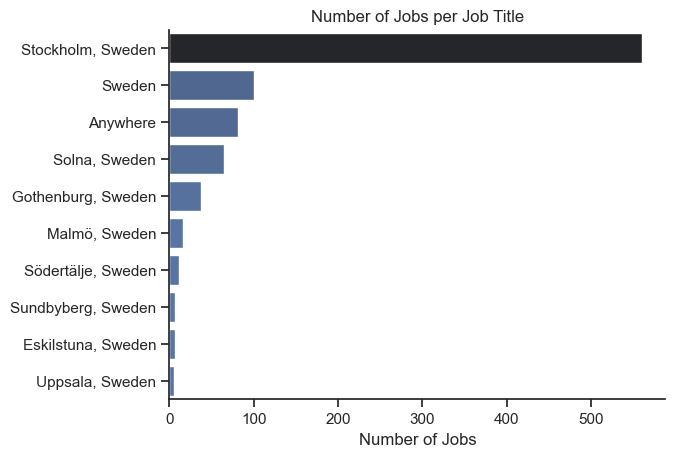

In [ ]:
df_plot = df_da_swe['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data = df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend = False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

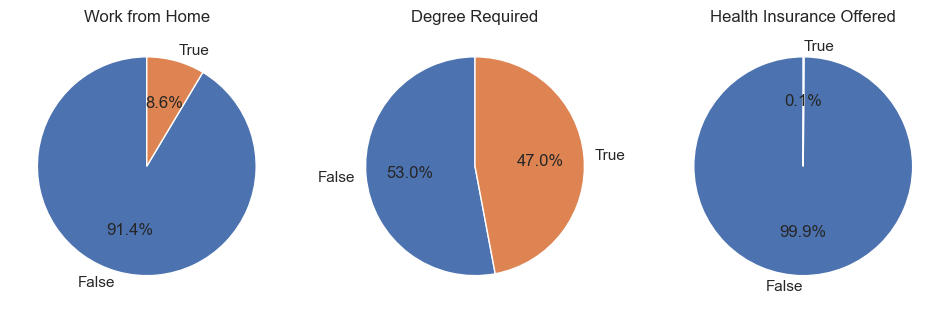

In [45]:
dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Degree Required',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_da_swe[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['False', 'True'])
    ax[i].set_title(title)
   
    
plt.show()

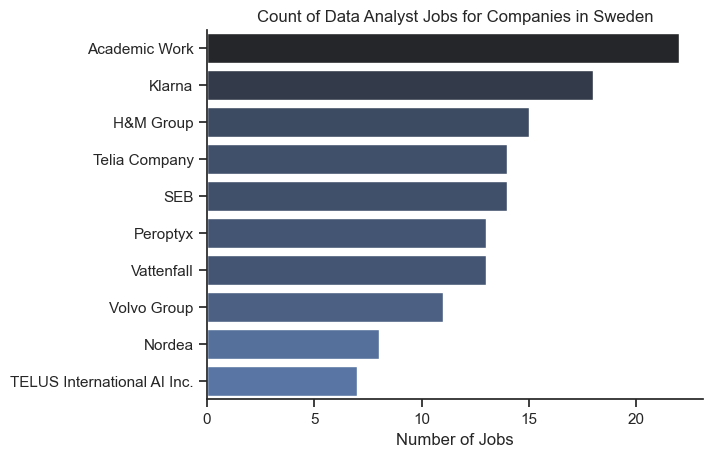

In [48]:
df_plot = df_da_swe['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data = df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend = False)
sns.despine()
plt.title('Count of Data Analyst Jobs for Companies in Sweden')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()